# Analisis Data Awal: NYC Airbnb 2019

Notebook ini disusun dengan bahasa yang disederhanakan:

1. Analisis Data Awal = mengenali data sebelum membuat prediksi.
2. Tujuan = mengubah data mentah yang membingungkan menjadi fakta yang berguna.
3. Penghematan Memori = pilih kolom yang penting saja dan saring data tidak masuk akal di awal agar komputer tidak lemot.
4. Visual bukan hiasan: setiap grafik wajib menjawab pertanyaan bisnis.
5. Memastikan Keterwakilan Data: pastikan sebagian data yang diambil (sampel) mewakili seluruh populasi.
6. Tulis batasan analisis dan saran yang masuk akal.

**Pertanyaan pendukung sebelum membuat grafik:**

> Grafik ini dibuat untuk menjawab keputusan apa, dan tindakan apa yang berubah jika polanya berbeda?

---
### Kamus Data (Penjelasan Kolom)
- **`id`**: ID unik untuk setiap properti.
- **`host_id`**: Identitas dari sang pemilik properti.
- **`neighbourhood_group`**: Wilayah besar / Kabupaten (seperti Manhattan, Brooklyn).
- **`neighbourhood`**: Area spesifik / Kelurahan di dalam wilayah besar tersebut.
- **`latitude` / `longitude`**: Koordinat peta lokasi properti.
- **`room_type`**: Tipe properti (Apakah penyewa menyewa seluruh rumah/apartemen, atau hanya satu kamar saja?).
- **`price`**: Harga sewa per malam (dalam dolar).
- **`minimum_nights`**: Syarat minimal menginap (membantu membedakan penyewa harian vs jangka panjang).
- **`number_of_reviews`**: Berapa kali properti ini pernah diulas (menunjukkan seberapa sering disewa).
- **`last_review`**: Tanggal ulasan terakhir diberikan.
- **`reviews_per_month`**: Rata-rata ulasan yang masuk tiap bulan (indikator tingkat kelarisan properti).
- **`calculated_host_listings_count`**: Jumlah properti yang dimiliki oleh satu pemilik yang sama (menandakan host perorangan vs juragan properti).
- **`availability_365`**: Ketersediaan properti sepanjang tahun atau 365 hari (angka rendah berarti tempat ini sering penuh dipesan).

In [53]:
import warnings
!pip install kagglehub
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

# Download latest version
dataset_handle = "dgomonov/new-york-city-airbnb-open-data"
path = kagglehub.dataset_download(dataset_handle)

print("Path to dataset files:", path)

Path to dataset files: C:\Users\erlanggadewa\.cache\kagglehub\datasets\dgomonov\new-york-city-airbnb-open-data\versions\3


In [54]:
# Langkah penghematan 1: Ambil informasi yang digunakan saja
selected_cols = [
    "id",
    "host_id",
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    "price",
    "minimum_nights",
    "number_of_reviews",
    "last_review",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
]

# last_review diparse saat load untuk efisiensi langkah berikutnya
df_raw = pd.read_csv(
    f"{path}/AB_NYC_2019.csv",
    usecols=selected_cols,
    parse_dates=["last_review"],
)

# Langkah penghematan 2: Buang data yang tidak masuk akal (harga 0, koordinat di luar wilayah) sejak awal
mask_valid = (
    (df_raw["price"] > 0)
    & (df_raw["availability_365"].between(0, 365))
    & (df_raw["latitude"].between(40.45, 40.95))
    & (df_raw["longitude"].between(-74.30, -73.65))
)

df = df_raw.loc[mask_valid].copy()

print(f"Baris awal (keseluruhan): {len(df_raw):,}")
print(f"Baris setelah pembersihan data rusak: {len(df):,}")
print(f"Baris terbuang: {len(df_raw) - len(df):,}")

df.head(5)

Baris awal (keseluruhan): 48,895
Baris setelah pembersihan data rusak: 48,884
Baris terbuang: 11


,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365
3,3831,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [55]:
def fmt_num(x, digits=2):
    if pd.isna(x):
        return "NA"
    if abs(x) >= 1000:
        return f"{x:,.{digits}f}"
    return f"{x:.{digits}f}"


def ask_plot(question):
    display(Markdown(f"**Pertanyaan grafik:** {question}"))


def explain_plot(points):
    bullet_text = "\n".join([f"- {p}" for p in points])
    display(Markdown(f"**Interpretasi :**\n{bullet_text}"))


def section(title):
    display(Markdown(f"## {title}"))

## Langkah 1: Pemeriksaan Awal dan Kelengkapan Data

,indikator,nilai
0,jumlah_baris,48884
1,jumlah_kolom,14
2,duplikasi_baris,0


### Tabel Bagian Data yang Kosong (Missing Value)

,missing_count,missing_pct
last_review,10051,20.56092
reviews_per_month,10051,20.56092
id,0,0.00000
host_id,0,0.00000
neighbourhood_group,0,0.00000
neighbourhood,0,0.00000
latitude,0,0.00000
longitude,0,0.00000
room_type,0,0.00000
price,0,0.00000


### Tabel Jumlah Variasi Kategori Data

,kolom_kategorikal,jumlah_kategori_unik
0,neighbourhood_group,5
1,neighbourhood,221
2,room_type,3


**Pertanyaan grafik:** Informasi mana yang paling banyak kosong, dan adakah alasannya?

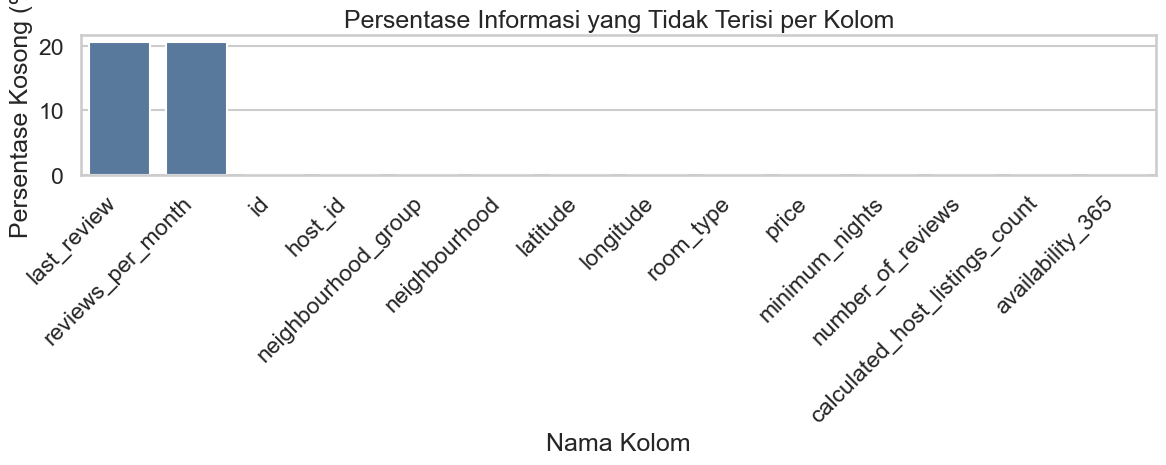

**Interpretasi :**
- Dua informasi yang paling sering kosong adalah ulasan terakhir (20.56%) dan rata-rata ulasan per bulan (20.56%).
- Menariknya, 100.00% dari data yang kosong di dua tempat ini selalu terjadi bersamaan. Ini menandakan **properti tersebut memang belum pernah mendapat pesanan/ulasan**.
- Artinya sifat kosong ini bukan karena datanya rusak, melainkan fakta bisnis bahwa properti tersebut pendatang baru atau sepi peminat.

In [56]:
section("Langkah 1: Pemeriksaan Awal dan Kelengkapan Data")

shape_df = pd.DataFrame(
    {
        "indikator": ["jumlah_baris", "jumlah_kolom", "duplikasi_baris"],
        "nilai": [len(df), df.shape[1], int(df.duplicated().sum())],
    }
)

display(shape_df)

missing_tbl = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda x: 100 * x["missing_count"] / len(df))
    .sort_values("missing_pct", ascending=False)
)

cardinality_tbl = pd.DataFrame(
    {
        "kolom_kategorikal": ["neighbourhood_group", "neighbourhood", "room_type"],
        "jumlah_kategori_unik": [
            df["neighbourhood_group"].nunique(),
            df["neighbourhood"].nunique(),
            df["room_type"].nunique(),
        ],
    }
)

display(Markdown("### Tabel Bagian Data yang Kosong (Missing Value)"))
display(missing_tbl)

display(Markdown("### Tabel Jumlah Variasi Kategori Data"))
display(cardinality_tbl)

ask_plot("Informasi mana yang paling banyak kosong, dan adakah alasannya?")
missing_plot = missing_tbl.reset_index().rename(columns={"index": "kolom_informasi"})
plt.figure(figsize=(12, 5))
sns.barplot(data=missing_plot, x="kolom_informasi", y="missing_pct", color="#4C78A8")
plt.title("Persentase Informasi yang Tidak Terisi per Kolom")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Persentase Kosong (%)")
plt.xlabel("Nama Kolom")
plt.tight_layout()
plt.show()

missing_last_review = missing_tbl.loc["last_review", "missing_pct"] if "last_review" in missing_tbl.index else np.nan
missing_rpm = missing_tbl.loc["reviews_per_month", "missing_pct"] if "reviews_per_month" in missing_tbl.index else np.nan
null_sync = (df["last_review"].isna() == df["reviews_per_month"].isna()).mean() * 100

explain_plot(
    [
        f"Dua informasi yang paling sering kosong adalah ulasan terakhir ({fmt_num(missing_last_review)}%) dan rata-rata ulasan per bulan ({fmt_num(missing_rpm)}%).",
        f"Menariknya, {fmt_num(null_sync)}% dari data yang kosong di dua tempat ini selalu terjadi bersamaan. Ini menandakan **properti tersebut memang belum pernah mendapat pesanan/ulasan**.",
        "Artinya sifat kosong ini bukan karena datanya rusak, melainkan fakta bisnis bahwa properti tersebut pendatang baru atau sepi peminat.",
    ]
)

## Langkah 2: Memastikan Sebagian Data (Sampel) Mewakili Seluruh Populasi

**Pertanyaan grafik:** Apakah sebaran kabupaten (Borough) pada sampel sama dengan aslinya?

,persentase_seluruh,persentase_sampel,selisih_poin
neighbourhood_group,,,
Manhattan,44.31,44.14,0.16
Brooklyn,41.11,41.28,0.17
Queens,11.59,11.46,0.14
Bronx,2.23,2.29,0.06
Staten Island,0.76,0.83,0.07


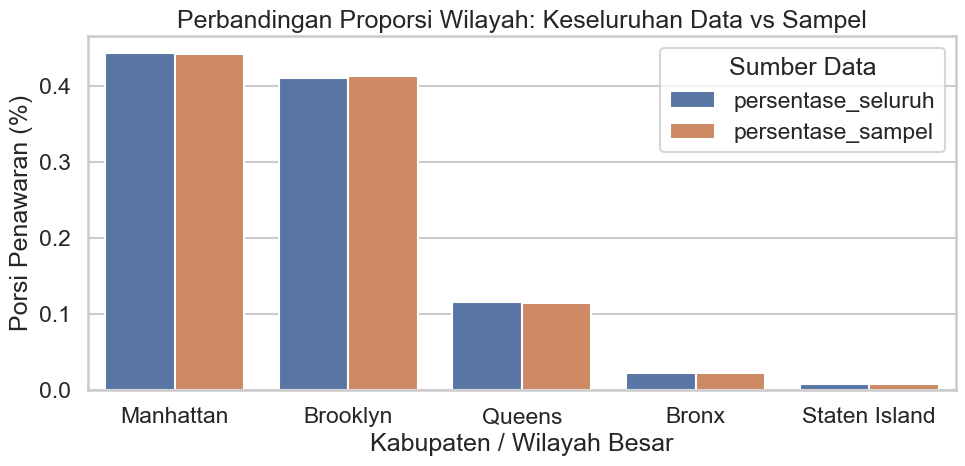

**Interpretasi :**
- Kabar baik: Jarak (selisih) porsi properti antara data asli dan sampel di tingkat wilayah adalah maksimal hanya 0.17%.
- **Apa artinya?** Memotong data menjadi jumlah kecil (sampel) ini **aman** secara geografis, tidak membuat satu kabupaten dominan menghilang.
- Hal ini penting agar analisis uji coba kita tidak menyimpang dari kenyataan populasi.

In [57]:
section("Langkah 2: Memastikan Sebagian Data (Sampel) Mewakili Seluruh Populasi")

# Ambil sampel terkontrol untuk simulasi kerja skala besar
sample_frac = 0.20
sample_df = df.sample(frac=sample_frac, random_state=42)

ask_plot("Apakah sebaran kabupaten (Borough) pada sampel sama dengan aslinya?")

global_borough = df["neighbourhood_group"].value_counts(normalize=True).rename("persentase_seluruh")
sample_borough = sample_df["neighbourhood_group"].value_counts(normalize=True).rename("persentase_sampel")
borough_compare = (
    pd.concat([global_borough, sample_borough], axis=1)
    .fillna(0)
    .assign(selisih_poin=lambda x: (x["persentase_seluruh"] - x["persentase_sampel"]).abs() * 100)
    .sort_values("persentase_seluruh", ascending=False)
)

borough_display = borough_compare.copy()
borough_display[["persentase_seluruh", "persentase_sampel"]] = borough_display[["persentase_seluruh", "persentase_sampel"]] * 100
display(borough_display.round(2))

borough_plot = borough_compare.reset_index()
first_col = borough_plot.columns[0]
borough_plot = borough_plot.rename(columns={first_col: "kabupaten"})
borough_plot = borough_plot.melt(
    id_vars="kabupaten",
    value_vars=["persentase_seluruh", "persentase_sampel"],
    var_name="sumber",
    value_name="proporsi",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=borough_plot, x="kabupaten", y="proporsi", hue="sumber")
plt.title("Perbandingan Proporsi Wilayah: Keseluruhan Data vs Sampel")
plt.ylabel("Porsi Penawaran (%)")
plt.xlabel("Kabupaten / Wilayah Besar")
plt.legend(title="Sumber Data")
plt.tight_layout()
plt.show()

max_gap_borough = borough_compare["selisih_poin"].max()
explain_plot(
    [
        f"Kabar baik: Jarak (selisih) porsi properti antara data asli dan sampel di tingkat wilayah adalah maksimal hanya {fmt_num(max_gap_borough)}%.",
        "**Apa artinya?** Memotong data menjadi jumlah kecil (sampel) ini **aman** secara geografis, tidak membuat satu kabupaten dominan menghilang.",
        "Hal ini penting agar analisis uji coba kita tidak menyimpang dari kenyataan populasi.",
    ]
)

**Pertanyaan grafik:** Apakah sebaran harga uang sewanya pada sampel juga mendekati harga global (aslinya)?

,kuantil,harga_global,harga_sampel,selisih_harga_absolut
0,0.10,49.0,49.00,0.00
1,0.25,69.0,69.00,0.00
2,0.50,106.0,107.00,1.00
3,0.75,175.0,176.00,1.00
4,0.90,269.0,270.00,1.00
5,0.99,799.0,799.24,0.24


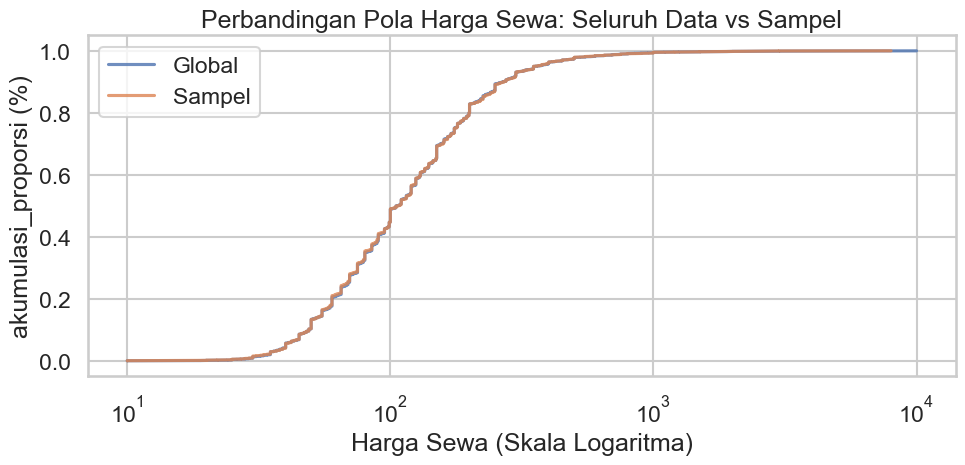

**Interpretasi :**
- Rata-rata beda harga di titik-titik pembagian kelompok harga hanya 0.54 dolar.
- Dua garis biru dan oranye pada grafik ini nyaris bertumpuk rata, ini tanda yang **sangat positif**.
- Artinya, profil harga penginapan, dari yang paling murah hingga mewah, tetap tersaji proporsional walaupun kita menggunakan hanya sedikit (sampel) data saja.

In [58]:
ask_plot("Apakah sebaran harga uang sewanya pada sampel juga mendekati harga global (aslinya)?")

q = [0.1, 0.25, 0.5, 0.75, 0.9, 0.99]
price_comp = pd.DataFrame(
    {
        "kuantil": q,
        "harga_global": df["price"].quantile(q).values,
        "harga_sampel": sample_df["price"].quantile(q).values,
    }
)
price_comp["selisih_harga_absolut"] = (price_comp["harga_global"] - price_comp["harga_sampel"]).abs()
display(price_comp)

plt.figure(figsize=(10, 5))
for dset, label in [(df, "Global"), (sample_df, "Sampel")]:
    x = np.sort(dset["price"].values)
    y = np.arange(1, len(x) + 1) / len(x)
    plt.plot(x, y, label=label, alpha=0.8)
plt.xscale("log")
plt.title("Perbandingan Pola Harga Sewa: Seluruh Data vs Sampel")
plt.xlabel("Harga Sewa (Skala Logaritma)")
plt.ylabel("akumulasi_proporsi (%)")
plt.legend()
plt.tight_layout()
plt.show()

mean_abs_gap_quantile = price_comp["selisih_harga_absolut"].mean()
explain_plot(
    [
        f"Rata-rata beda harga di titik-titik pembagian kelompok harga hanya {fmt_num(mean_abs_gap_quantile)} dolar.",
        "Dua garis biru dan oranye pada grafik ini nyaris bertumpuk rata, ini tanda yang **sangat positif**.",
        "Artinya, profil harga penginapan, dari yang paling murah hingga mewah, tetap tersaji proporsional walaupun kita menggunakan hanya sedikit (sampel) data saja.",
    ]
)

## Langkah 3: Karakteristik Indikator Bisnis Utama (Harga & Sewa)

**Pertanyaan grafik:** Apa kelas tarif terbanyak, apakah didominasi harga 'murah' atau 'wah'?

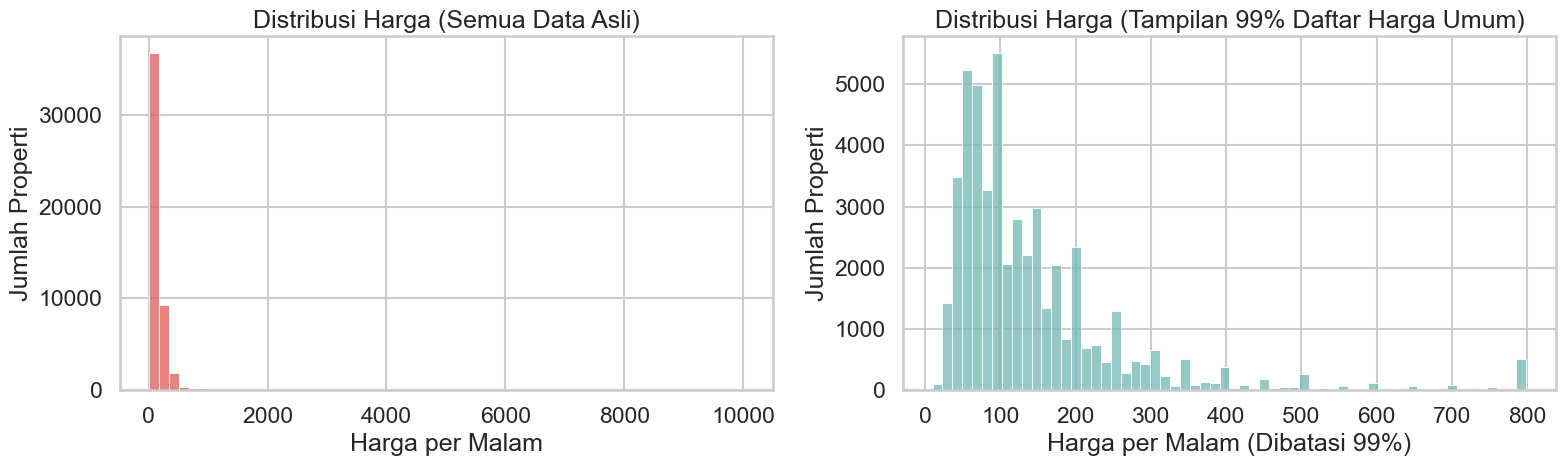

**Interpretasi :**
- Separuh keseluruhan penyewa menawarkan harga malamnya **di bawah atau sama dengan 106.00 dolar**.
- Lalu, rata-rata harganya tampak ditarik sangat melompat ke **152.76 dolar**. **Mengapa bisa?** Karena ada properti sultan yang ditawarkan 269.00 dolar sangat mahal ke atas yang menaikkan rata-rata itu secara keseluruhan.
- Nilai tertinggi yang ditawarkan adalah 10,000.00 dolar.
- Saran: Pakailah angka tengah (**nilai tipikal 50% data terbawah**), karena rata-rata dapat 'berbohong' jika digabungkan bersama properti elit yang jumlahnya sedikit.

In [59]:
section("Langkah 3: Karakteristik Indikator Bisnis Utama (Harga & Sewa)")

# Versi data untuk visual yang sensitif outlier
price_hi = df["price"].quantile(0.99)
min_nights_hi = df["minimum_nights"].quantile(0.99)

df_vis = df.copy()
df_vis["price_capped"] = df_vis["price"].clip(upper=price_hi)
df_vis["minimum_nights_capped"] = df_vis["minimum_nights"].clip(upper=min_nights_hi)

ask_plot("Apa kelas tarif terbanyak, apakah didominasi harga 'murah' atau 'wah'?")
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df["price"], bins=60, ax=ax[0], color="#E45756")
ax[0].set_title("Distribusi Harga (Semua Data Asli)")
ax[0].set_xlabel("Harga per Malam")
ax[0].set_ylabel("Jumlah Properti")

sns.histplot(df_vis["price_capped"], bins=60, ax=ax[1], color="#72B7B2")
ax[1].set_title("Distribusi Harga (Tampilan 99% Daftar Harga Umum)")
ax[1].set_xlabel("Harga per Malam (Dibatasi 99%)")
ax[1].set_ylabel("Jumlah Properti")

plt.tight_layout()
plt.show()

median_price = df["price"].median()
mean_price = df["price"].mean()
q90_price = df["price"].quantile(0.90)
max_price = df["price"].max()
explain_plot(
    [
        f"Separuh keseluruhan penyewa menawarkan harga malamnya **di bawah atau sama dengan {fmt_num(median_price)} dolar**.",
        f"Lalu, rata-rata harganya tampak ditarik sangat melompat ke **{fmt_num(mean_price)} dolar**. **Mengapa bisa?** Karena ada properti sultan yang ditawarkan {fmt_num(q90_price)} dolar sangat mahal ke atas yang menaikkan rata-rata itu secara keseluruhan.",
        f"Nilai tertinggi yang ditawarkan adalah {fmt_num(max_price)} dolar.",
        "Saran: Pakailah angka tengah (**nilai tipikal 50% data terbawah**), karena rata-rata dapat 'berbohong' jika digabungkan bersama properti elit yang jumlahnya sedikit.",
    ]
)

**Pertanyaan grafik:** Apa syarat sewa menginap terumum (minimum malam)? Apakah lebih sering disewa musiman atau jangka panjang?

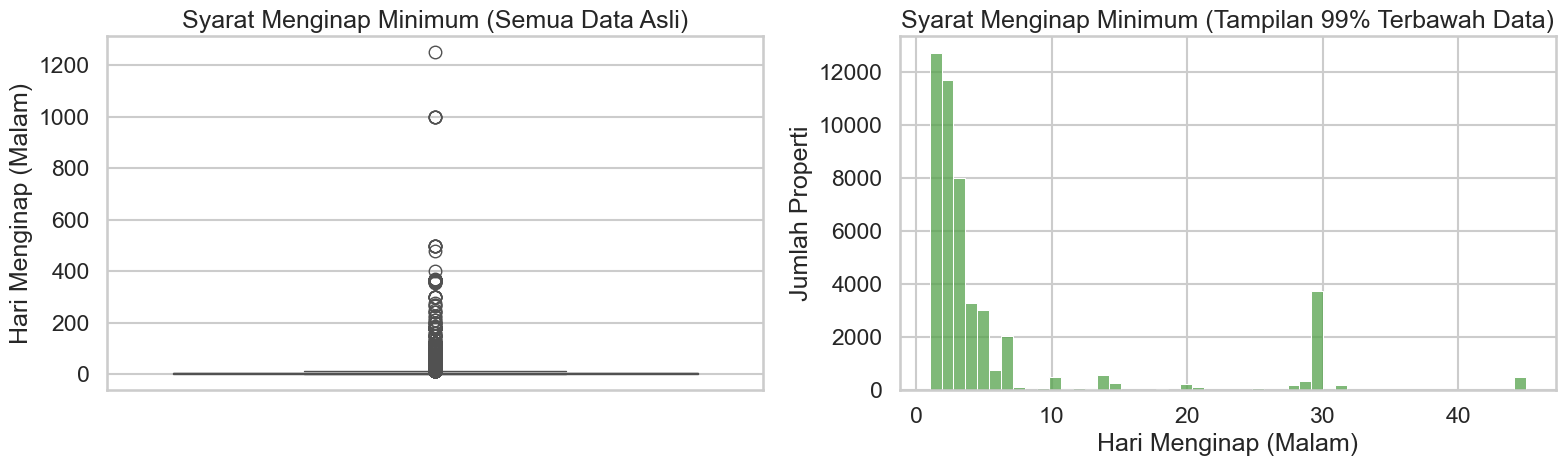

**Interpretasi :**
- Separuh keseluruhan daftar di platform ini mewajibkan minimum pesanan **3.00 malam** saja (tipe pelancong singgah/kunjungan singkat).
- Namun, ada batasan minoritas elit sebesar **28.00 malam**. Sebagian kecil peminat sewa ini beroperasi bulanan atau menetap agak lama, lebih ke indekos ketimbang model hotel harian.
- Saran: Bagilah dua model operasi bisnis: pasar penginapan pelancong akhir pekan (jangka pendek) dan pasar sewa panjang.

In [60]:
ask_plot("Apa syarat sewa menginap terumum (minimum malam)? Apakah lebih sering disewa musiman atau jangka panjang?")
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(y=df["minimum_nights"], ax=ax[0], color="#F58518")
ax[0].set_title("Syarat Menginap Minimum (Semua Data Asli)")
ax[0].set_ylabel("Hari Menginap (Malam)")

sns.histplot(df_vis["minimum_nights_capped"], bins=50, ax=ax[1], color="#54A24B")
ax[1].set_title("Syarat Menginap Minimum (Tampilan 99% Terbawah Data)")
ax[1].set_xlabel("Hari Menginap (Malam)")
ax[1].set_ylabel("Jumlah Properti")

plt.tight_layout()
plt.show()

median_min_nights = df["minimum_nights"].median()
q90_min_nights = df["minimum_nights"].quantile(0.90)

explain_plot(
    [
        f"Separuh keseluruhan daftar di platform ini mewajibkan minimum pesanan **{fmt_num(median_min_nights)} malam** saja (tipe pelancong singgah/kunjungan singkat).",
        f"Namun, ada batasan minoritas elit sebesar **{fmt_num(q90_min_nights)} malam**. Sebagian kecil peminat sewa ini beroperasi bulanan atau menetap agak lama, lebih ke indekos ketimbang model hotel harian.",
        "Saran: Bagilah dua model operasi bisnis: pasar penginapan pelancong akhir pekan (jangka pendek) dan pasar sewa panjang.",
    ]
)

**Pertanyaan grafik:** Tipe properti mana yang paling laris diminati pengunjung (berdasarkan cepatnya ulasan masuk tiap bulan)?

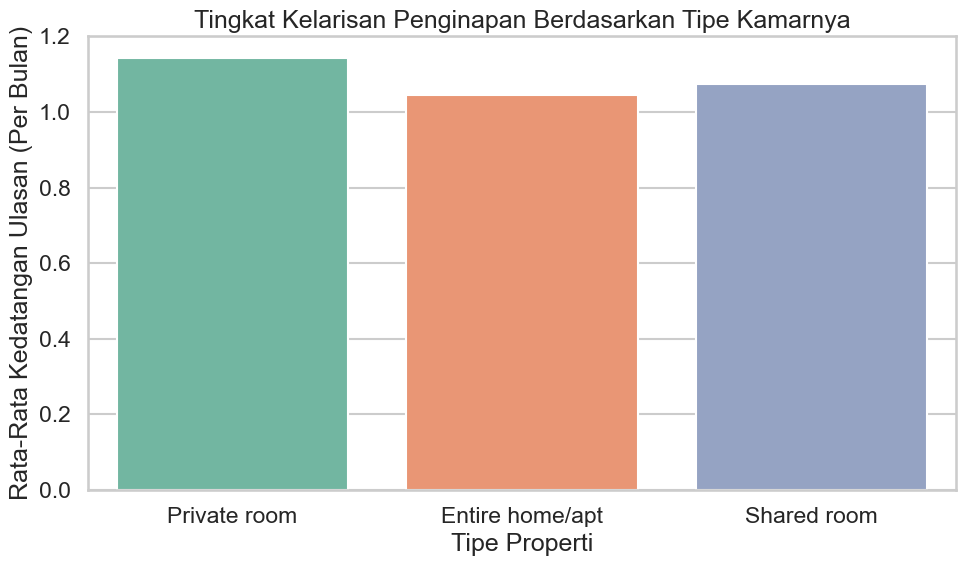

**Interpretasi :**
- Tipe properti **Private room** adalah yang perputaran tamunya paling cepat, mendapat rata-rata **1.14 ulasan baru setiap bulannya**.
- Sebaliknya, tipe **Entire home/apt** cenderung lebih pelan sirkulasi tamunya.
- Penjelasan logisnya: Menyewa satu kamar saja (`Private room`) umumnya lebih terjangkau, sehingga sangat disukai pelancong tunggal yang hanya butuh tidur 1-2 malam. Akibatnya tamu cepat berganti tiap harinya.
- Sedangkan menyewa rumah utuh (`Entire home/apt`) biasanya dilakukan oleh rombongan keluarga yang liburan lebih lama, sehingga tamu tidak berganti secepat kamar privat.

In [61]:
ask_plot("Tipe properti mana yang paling laris diminati pengunjung (berdasarkan cepatnya ulasan masuk tiap bulan)?")

plt.figure(figsize=(10, 6))
# Mengisi ulasan kosong dengan 0, lalu menghitung rata-rata ulasan per tipe kamar
sns.barplot(
    data=df.fillna({"reviews_per_month": 0}),
    x="room_type",
    y="reviews_per_month",
    palette="Set2",
    errorbar=None # Menghilangkan garis error agar grafik lebih bersih dan mudah dibaca
)
plt.title("Tingkat Kelarisan Penginapan Berdasarkan Tipe Kamarnya")
plt.xlabel("Tipe Properti")
plt.ylabel("Rata-Rata Kedatangan Ulasan (Per Bulan)")
plt.tight_layout()
plt.show()

# Menghitung urutan tipe kamar paling laris untuk teks kesimpulan
rpm_by_room = df.fillna({"reviews_per_month": 0}).groupby("room_type")["reviews_per_month"].mean().sort_values(ascending=False)
top_room = rpm_by_room.index[0]
top_rpm = rpm_by_room.iloc[0]
bottom_room = rpm_by_room.index[-1]

explain_plot(
    [
        f"Tipe properti **{top_room}** adalah yang perputaran tamunya paling cepat, mendapat rata-rata **{fmt_num(top_rpm)} ulasan baru setiap bulannya**.",
        f"Sebaliknya, tipe **{bottom_room}** cenderung lebih pelan sirkulasi tamunya.",
        "Penjelasan logisnya: Menyewa satu kamar saja (`Private room`) umumnya lebih terjangkau, sehingga sangat disukai pelancong tunggal yang hanya butuh tidur 1-2 malam. Akibatnya tamu cepat berganti tiap harinya.",
        "Sedangkan menyewa rumah utuh (`Entire home/apt`) biasanya dilakukan oleh rombongan keluarga yang liburan lebih lama, sehingga tamu tidak berganti secepat kamar privat.",
    ]
)

## Langkah 4: Membaca Pasar Berdasarkan Tipe Properti & Kabupatennnya

**Pertanyaan grafik:** Apa kelas tarif sewa termahal berdasarkan wilayah atau tipe kamarnya (rumah utuh vs indekos)?

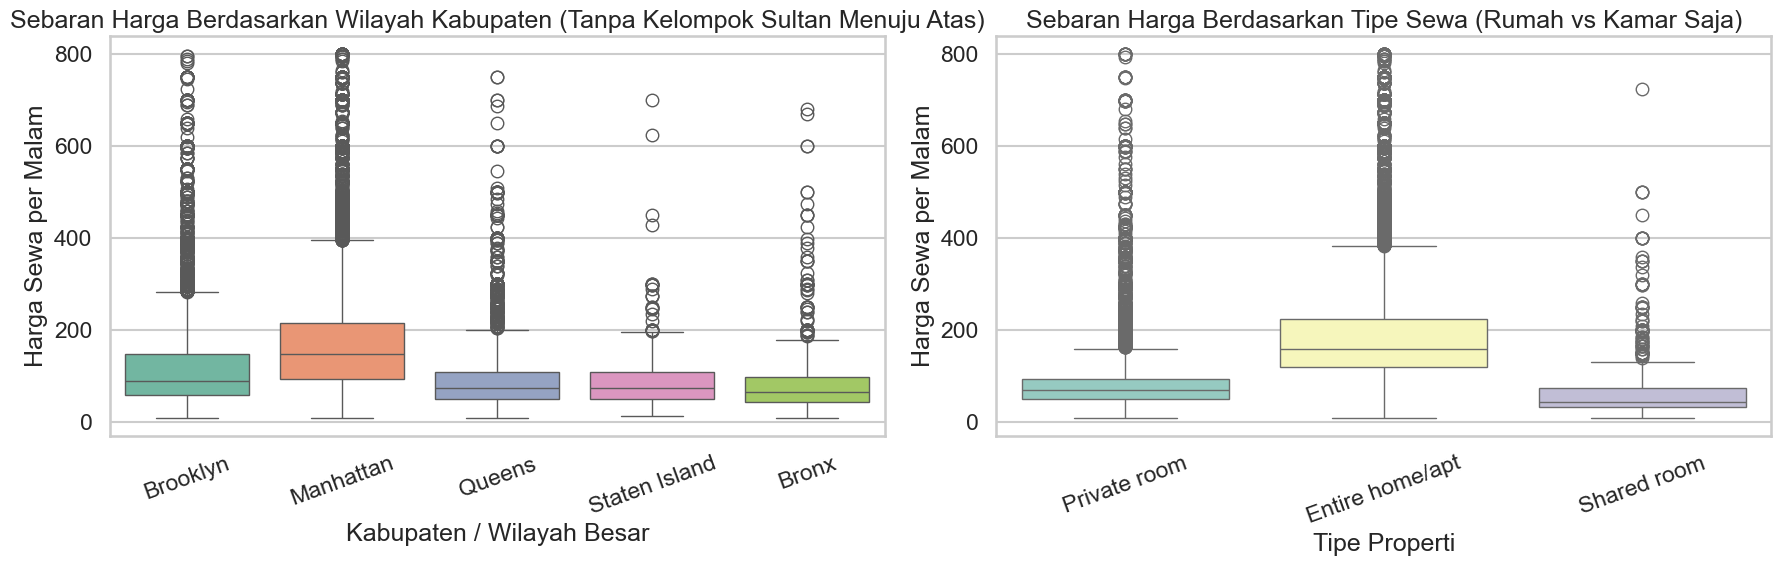

,neighbourhood_group,room_type,harga_nilai_tengah
6,Manhattan,Entire home/apt,191.0
3,Brooklyn,Entire home/apt,145.0
9,Queens,Entire home/apt,120.0
0,Bronx,Entire home/apt,100.0
12,Staten Island,Entire home/apt,100.0
7,Manhattan,Private room,90.0
8,Manhattan,Shared room,69.0
4,Brooklyn,Private room,65.0
10,Queens,Private room,60.0
1,Bronx,Private room,54.0


**Interpretasi :**
- Tipe pesanan yang selalu dihargai pasaran tertinggi jatuh di **Manhattan - Entire home/apt** (bernilai separuhnya di atas 191.00 dolar).
- Sedangkan opsi terjangkau jatuh pada daerah pinggiran di **Staten Island - Shared room** (hanya sekitar 30.00 dolar).
- Pemandangan seperti ini menegaskan **jika kita hanya mematok harga yang sama antar kota yang miskin vs kota metropolitan elit, bisa gagal fatal (kemahalan di satu titik atau dirugikan akibat terlalu murah di sisi lainnya).**

In [62]:
section("Langkah 4: Membaca Pasar Berdasarkan Tipe Properti & Kabupatennnya")

ask_plot("Apa kelas tarif sewa termahal berdasarkan wilayah atau tipe kamarnya (rumah utuh vs indekos)?")
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(
    data=df_vis[df_vis["price"] <= price_hi],
    x="neighbourhood_group",
    y="price",
    ax=ax[0],
    palette="Set2",
)
ax[0].set_title("Sebaran Harga Berdasarkan Wilayah Kabupaten (Tanpa Kelompok Sultan Menuju Atas)")
ax[0].set_xlabel("Kabupaten / Wilayah Besar")
ax[0].set_ylabel("Harga Sewa per Malam")
ax[0].tick_params(axis="x", rotation=20)

sns.boxplot(
    data=df_vis[df_vis["price"] <= price_hi],
    x="room_type",
    y="price",
    ax=ax[1],
    palette="Set3",
)
ax[1].set_title("Sebaran Harga Berdasarkan Tipe Sewa (Rumah vs Kamar Saja)")
ax[1].set_xlabel("Tipe Properti")
ax[1].set_ylabel("Harga Sewa per Malam")
ax[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

price_segment = (
    df.groupby(["neighbourhood_group", "room_type"])["price"]
    .median()
    .rename("harga_nilai_tengah")
    .reset_index()
    .sort_values("harga_nilai_tengah", ascending=False)
)
display(price_segment.head(20))

highest_segment = price_segment.iloc[0]
lowest_segment = price_segment.iloc[-1]

explain_plot(
    [
        (
            "Tipe pesanan yang selalu dihargai pasaran tertinggi jatuh di "
            f"**{highest_segment['neighbourhood_group']} - {highest_segment['room_type']}** "
            f"(bernilai separuhnya di atas {fmt_num(highest_segment['harga_nilai_tengah'])} dolar)."
        ),
        (
            "Sedangkan opsi terjangkau jatuh pada daerah pinggiran di "
            f"**{lowest_segment['neighbourhood_group']} - {lowest_segment['room_type']}** "
            f"(hanya sekitar {fmt_num(lowest_segment['harga_nilai_tengah'])} dolar)."
        ),
        "Pemandangan seperti ini menegaskan **jika kita hanya mematok harga yang sama antar kota yang miskin vs kota metropolitan elit, bisa gagal fatal (kemahalan di satu titik atau dirugikan akibat terlalu murah di sisi lainnya).**",
    ]
)

**Pertanyaan grafik:** Kawasan (kelurahan) manakah pusat penyumbang properti terbesar?

,jumlah_penginapan,harga_nilai_tengah
neighbourhood,,
Astoria,900,85.0
Lower East Side,911,139.0
Chelsea,1113,199.0
Greenpoint,1114,119.0
East Harlem,1117,99.0
Midtown,1545,210.0
Crown Heights,1564,85.0
Upper East Side,1798,149.0
East Village,1853,150.0


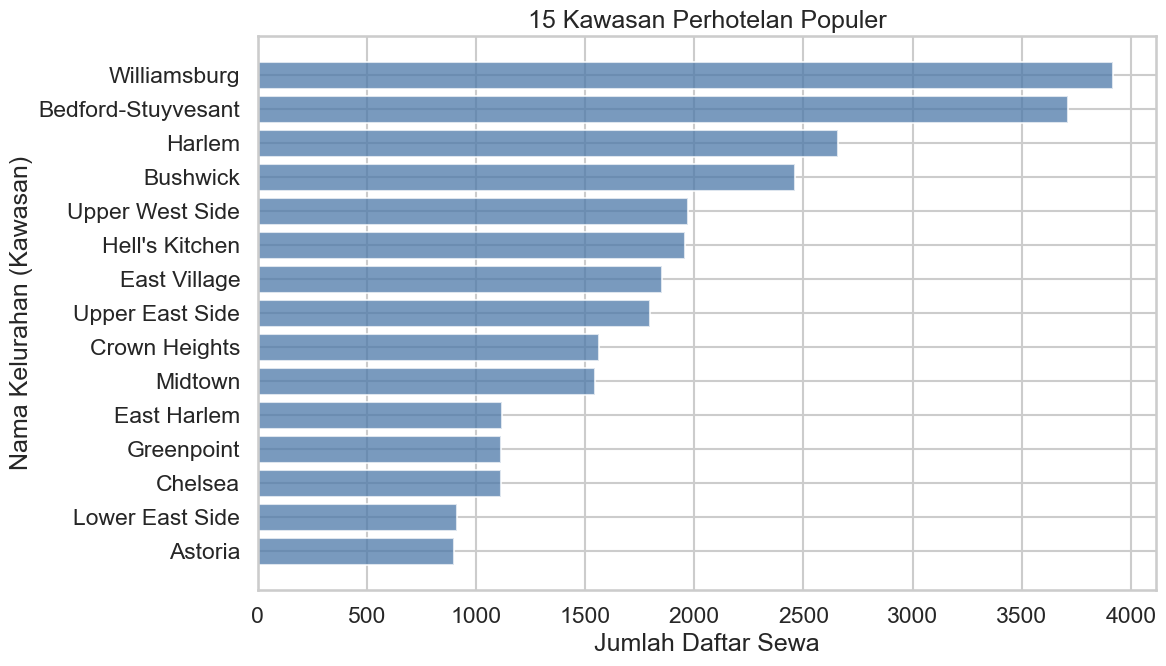

**Interpretasi :**
- **Pusat Keramaian Utama**: Kawasan **Williamsburg** menempati urutan pertama dengan sekitar **3,919.00** properti yang terdaftar.
- **Perbedaan Kelas Pasar**: 15 kawasan terpopuler ini tidak semuanya menyasar pasar yang sama. Ada kawasan elit (harga tengah mahal) dan kawasan hemat (harga tengah murah).
- **Strategi untuk Modal Besar**: Incar kawasan yang masuk dalam daftar Top 15 ini **DAN** memiliki *Harga Nilai Tengah* yang tinggi.
- **Strategi untuk Modal Terbatas**: Buka properti di kawasan Top 15 yang *Harga Nilai Tengah*-nya murah, agar penginapan Anda di sana tidak salah sasaran ke wisatawan hemat.

In [63]:
ask_plot("Kawasan (kelurahan) manakah pusat penyumbang properti terbesar?")

top_n = 15
top_neigh_count = df["neighbourhood"].value_counts().head(top_n)

top_neigh_price = (
    df[df["neighbourhood"].isin(top_neigh_count.index)]
    .groupby("neighbourhood")["price"]
    .median()
)

neigh_tbl = pd.DataFrame(
    {
        "jumlah_penginapan": top_neigh_count,
        "harga_nilai_tengah": top_neigh_price,
    }
).sort_values("jumlah_penginapan", ascending=True)

display(neigh_tbl)

fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.barh(neigh_tbl.index, neigh_tbl["jumlah_penginapan"], color="#4C78A8", alpha=0.75)
ax1.set_xlabel("Jumlah Daftar Sewa")
ax1.set_ylabel("Nama Kelurahan (Kawasan)")
ax1.set_title("15 Kawasan Perhotelan Populer")
plt.tight_layout()
plt.show()

top_area = neigh_tbl.index[-1]
top_count = neigh_tbl.iloc[-1]["jumlah_penginapan"]

explain_plot(
    [
        f"**Pusat Keramaian Utama**: Kawasan **{top_area}** menempati urutan pertama dengan sekitar **{fmt_num(top_count)}** properti yang terdaftar.",
        "**Perbedaan Kelas Pasar**: 15 kawasan terpopuler ini tidak semuanya menyasar pasar yang sama. Ada kawasan elit (harga tengah mahal) dan kawasan hemat (harga tengah murah).",
        "**Strategi untuk Modal Besar**: Incar kawasan yang masuk dalam daftar Top 15 ini **DAN** memiliki *Harga Nilai Tengah* yang tinggi.",
        "**Strategi untuk Modal Terbatas**: Buka properti di kawasan Top 15 yang *Harga Nilai Tengah*-nya murah, agar penginapan Anda di sana tidak salah sasaran ke wisatawan hemat.",
    ]
)

## Langkah 6: Peta Lokasi Mahal vs Murah (Pola Geografis Sesungguhnya)

**Pertanyaan grafik:** Apa rupa pengelompokan wilayah ini, harga bersahabat dan sultan menumpuk di mana?

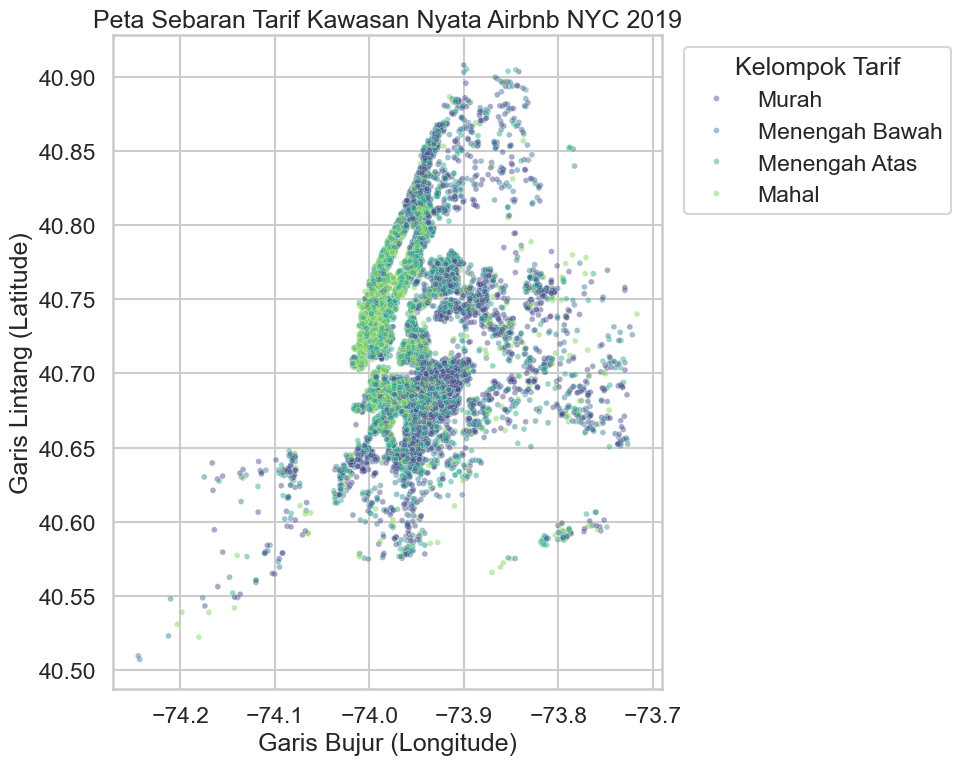

,harga_tengah_wilayah
neighbourhood_group,
Manhattan,150.0
Brooklyn,90.0
Queens,75.0
Staten Island,75.0
Bronx,65.0


**Interpretasi :**
- Pola titik pada peta tidak acak: kelompok Murah dan Menengah Bawah cenderung berkumpul di zona tertentu, sedangkan Menengah Atas dan Mahal membentuk kantong lokasi tersendiri.
- Tabel median menegaskan pola ini: wilayah dengan median tertinggi ada di **Manhattan**, sementara median terendah ada di **Bronx**, dengan selisih sekitar **85.00 dolar** per malam.
- Implikasi bisnisnya jelas: strategi harga tidak boleh seragam satu kota. Tetapkan pricing berbasis klaster wilayah agar tetap kompetitif di area sensitif harga dan tetap optimal di area premium.

In [64]:
section("Langkah 6: Peta Lokasi Mahal vs Murah (Pola Geografis Sesungguhnya)")

ask_plot("Apa rupa pengelompokan wilayah ini, harga bersahabat dan sultan menumpuk di mana?")

map_df = df.copy()
map_df["kelompok_tarif"] = pd.qcut(
    map_df["price"].rank(method="first"),
    q=4,
    labels=["Murah", "Menengah Bawah", "Menengah Atas", "Mahal"],
)

plot_map = map_df.sample(min(15000, len(map_df)), random_state=42)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=plot_map,
    x="longitude",
    y="latitude",
    hue="kelompok_tarif",
    alpha=0.45,
    s=18,
    palette="viridis",
)
plt.title("Peta Sebaran Tarif Kawasan Nyata Airbnb NYC 2019")
plt.xlabel("Garis Bujur (Longitude)")
plt.ylabel("Garis Lintang (Latitude)")
plt.legend(title="Kelompok Tarif", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

price_by_borough = df.groupby("neighbourhood_group")["price"].median().sort_values(ascending=False)
display(price_by_borough.to_frame("harga_tengah_wilayah"))

wilayah_termahal = price_by_borough.index[0]
wilayah_termurah = price_by_borough.index[-1]
selisih_median = price_by_borough.iloc[0] - price_by_borough.iloc[-1]

explain_plot(
    [
        "Pola titik pada peta tidak acak: kelompok Murah dan Menengah Bawah cenderung berkumpul di zona tertentu, sedangkan Menengah Atas dan Mahal membentuk kantong lokasi tersendiri.",
        (
            f"Tabel median menegaskan pola ini: wilayah dengan median tertinggi ada di **{wilayah_termahal}**, "
            f"sementara median terendah ada di **{wilayah_termurah}**, dengan selisih sekitar **{fmt_num(selisih_median)} dolar** per malam."
        ),
        "Implikasi bisnisnya jelas: strategi harga tidak boleh seragam satu kota. Tetapkan pricing berbasis klaster wilayah agar tetap kompetitif di area sensitif harga dan tetap optimal di area premium.",
    ]
)

In [65]:
section("Langkah 7: Meringkas Data")

# Mengelompokkan data level wilayah dan tipe kamar
stage_1 = (
    df.groupby(["neighbourhood_group", "room_type"], as_index=False)
    .agg(
        jumlah_penginapan=("id", "count"),
        rata_nilai_tengah_sewa=("price", "median"),
        skor_ulasan_laku_rata_rata=("reviews_per_month", "mean"),
    )
)

display(Markdown("### Ringkasan Data (Wilayah Besar x Tipe Kamar)"))
display(stage_1)

# Ekstrak temuan nilai yang menonjol dari tabel
penguasa_pasar = stage_1.sort_values('jumlah_penginapan', ascending=False).iloc[0]
paling_mahal = stage_1.sort_values('rata_nilai_tengah_sewa', ascending=False).iloc[0]
paling_laris = stage_1.sort_values('skor_ulasan_laku_rata_rata', ascending=False).iloc[0]

explain_plot(
    [
        f"**Fakta Menonjol 1 (Penguasa Pasar)**: Suplai terbanyak dipegang oleh tipe kamar **{penguasa_pasar['room_type']}** di **{penguasa_pasar['neighbourhood_group']}** dengan jumlah **{fmt_num(penguasa_pasar['jumlah_penginapan'])}** properti.",
        f"**Fakta Menonjol 2 (Kawasan Paling Eksklusif)**: Kombinasi paling elit adalah **{paling_mahal['room_type']}** di **{paling_mahal['neighbourhood_group']}** dengan harga tengah mencapai **{fmt_num(paling_mahal['rata_nilai_tengah_sewa'])} dolar** per malam.",
        f"**Fakta Menonjol 3 (Kombinasi Paling Laris Dipasan)**: Kombinasi tipe kamar **{paling_laris['room_type']}** di kawasan **{paling_laris['neighbourhood_group']}** memiliki tingkat ulasan paling ngebut didatangi tamu (**{fmt_num(paling_laris['skor_ulasan_laku_rata_rata'])} ulasan baru tiap bulan**).",
        "**Apa Fungsi Tabel Ringkasan Ini?**: Memberikan 'Kaca Pembesar' spesifik untuk melihat secara langsung pada satu tabel, kelompok kamar di kabupaten mana yang pasokannya terbesar, harganya termahal, dan lakunya paling cepat.",
        "**Tujuan Akhir EDA**: Susunan puluhan ribu baris data mentah kini berhasil dibekukan wujudnya menjadi indikator profil bisnis yang ringkas, praktis, dan akurat."
    ]
)

## Langkah 7: Meringkas Data

### Ringkasan Data (Wilayah Besar x Tipe Kamar)

,neighbourhood_group,room_type,jumlah_penginapan,rata_nilai_tengah_sewa,skor_ulasan_laku_rata_rata
0,Bronx,Entire home/apt,379,100.0,2.238123
1,Bronx,Private room,651,54.0,1.639904
2,Bronx,Shared room,60,40.0,1.351860
3,Brooklyn,Entire home/apt,9558,145.0,1.317773
4,Brooklyn,Private room,10126,65.0,1.254912
5,Brooklyn,Shared room,411,36.0,1.077118
6,Manhattan,Entire home/apt,13198,191.0,1.141610
7,Manhattan,Private room,7982,90.0,1.448949
8,Manhattan,Shared room,480,69.0,1.792781
9,Queens,Entire home/apt,2096,120.0,1.967302


**Interpretasi :**
- **Fakta Menonjol 1 (Penguasa Pasar)**: Suplai terbanyak dipegang oleh tipe kamar **Entire home/apt** di **Manhattan** dengan jumlah **13,198.00** properti.
- **Fakta Menonjol 2 (Kawasan Paling Eksklusif)**: Kombinasi paling elit adalah **Entire home/apt** di **Manhattan** dengan harga tengah mencapai **191.00 dolar** per malam.
- **Fakta Menonjol 3 (Kombinasi Paling Laris Dipasan)**: Kombinasi tipe kamar **Entire home/apt** di kawasan **Bronx** memiliki tingkat ulasan paling ngebut didatangi tamu (**2.24 ulasan baru tiap bulan**).
- **Apa Fungsi Tabel Ringkasan Ini?**: Memberikan 'Kaca Pembesar' spesifik untuk melihat secara langsung pada satu tabel, kelompok kamar di kabupaten mana yang pasokannya terbesar, harganya termahal, dan lakunya paling cepat.
- **Tujuan Akhir EDA**: Susunan puluhan ribu baris data mentah kini berhasil dibekukan wujudnya menjadi indikator profil bisnis yang ringkas, praktis, dan akurat.